# 03 — IPM Baseline Demo (Phase 3)

What this covers:
1. Load zero-shot SegFormer + compute IPM homography
2. Front-view 3-class segmentation mask
3. IPM warp → BEV mask
4. Side-by-side: front camera | seg mask | BEV output
5. Homography visualisation — where source points map to
6. Boston vs Singapore — IPM flat-ground assumption failure
7. Multi-frame strip — IPM output across 5 consecutive frames

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from utils.device import get_device
from utils.config import BEV, SEGFORMER, CLASSES

device = get_device(verbose=True)
print('Ready')

[device] Using: mps
[device] Apple MPS backend active - M3 GPU will be used.
Ready


## 1. Load zero-shot model + compute homography

In [2]:
from models.segformer.model import build_segformer_zero_shot
from data.nuscenes_loader import get_all_sample_tokens, get_camera_data
from ipm.homography import compute_ipm_homography, get_camera_height_from_nusc

model = build_segformer_zero_shot().to(device)
model.eval()

token    = get_all_sample_tokens()[0]
cam_data = get_camera_data(token)
K        = cam_data['K']
cam_h    = get_camera_height_from_nusc(token)
H        = compute_ipm_homography(K, camera_height=cam_h)

print(f'Camera height from calibration: {cam_h:.3f}m')
print(f'Homography H:\n{H}')

Camera height from calibration: 1.511m
Homography H:
[[ 9.6066622e-03 -3.5763735e-01  9.4981377e+01]
 [-3.4394233e-17 -3.5763723e-01  9.2213715e+01]
 [-5.8038487e-19 -3.5763734e-03  1.0000000e+00]]


## 2. Front-view segmentation (3-class)

Seg mask shape : (512, 1024)  unique: [0, 1, 2, 255]


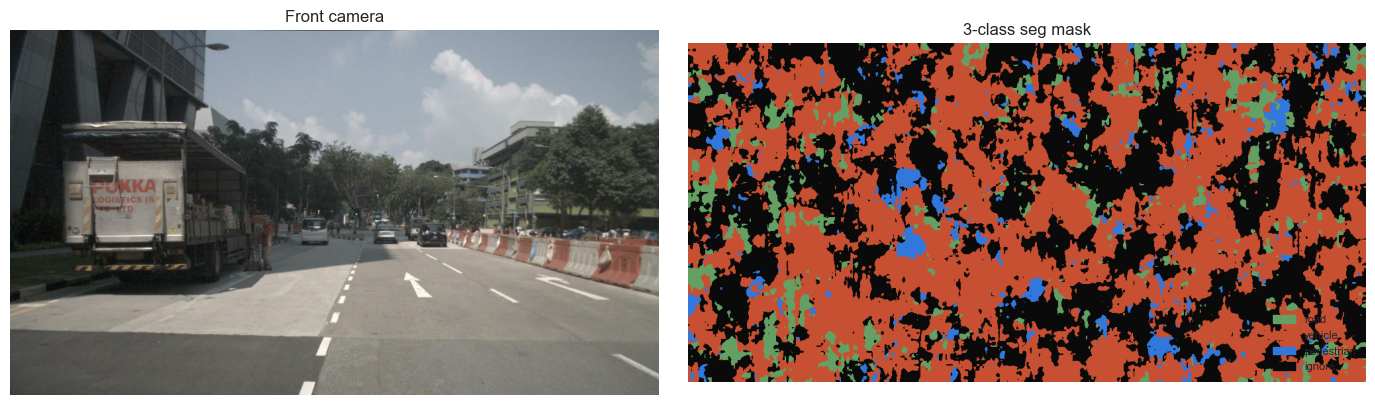

In [3]:
from models.segformer.inference import run_inference_3class
from viz.colorize import colorize_seg

bgr = cv2.imread(str(cam_data['image_path']))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

seg_3 = run_inference_3class(model, bgr, device)
print(f'Seg mask shape : {seg_3.shape}  unique: {np.unique(seg_3).tolist()}')

# use 3-class palette: road=green, vehicle=orange, ped=blue, ignore=black
palette = {0:(100,160,100), 1:(200,80,50), 2:(50,120,220), 255:(10,10,10)}
vis_3   = np.zeros((*seg_3.shape, 3), dtype=np.uint8)
for cls, col in palette.items():
    vis_3[seg_3==cls] = col

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].imshow(rgb);   axes[0].set_title('Front camera');       axes[0].axis('off')
axes[1].imshow(vis_3); axes[1].set_title('3-class seg mask');   axes[1].axis('off')
patches = [
    mpatches.Patch(color=np.array(palette[0])/255, label='road'),
    mpatches.Patch(color=np.array(palette[1])/255, label='vehicle'),
    mpatches.Patch(color=np.array(palette[2])/255, label='pedestrian'),
    mpatches.Patch(color=np.array(palette[255])/255, label='ignore'),
]
axes[1].legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

## 3. IPM warp → BEV mask

BEV mask shape    : (200, 200)
BEV mask unique   : [0, 1, 2, 255]
BEV channels shape: (3, 200, 200)
  drivable_area: 775 pixels
  vehicle: 6588 pixels
  pedestrian: 472 pixels


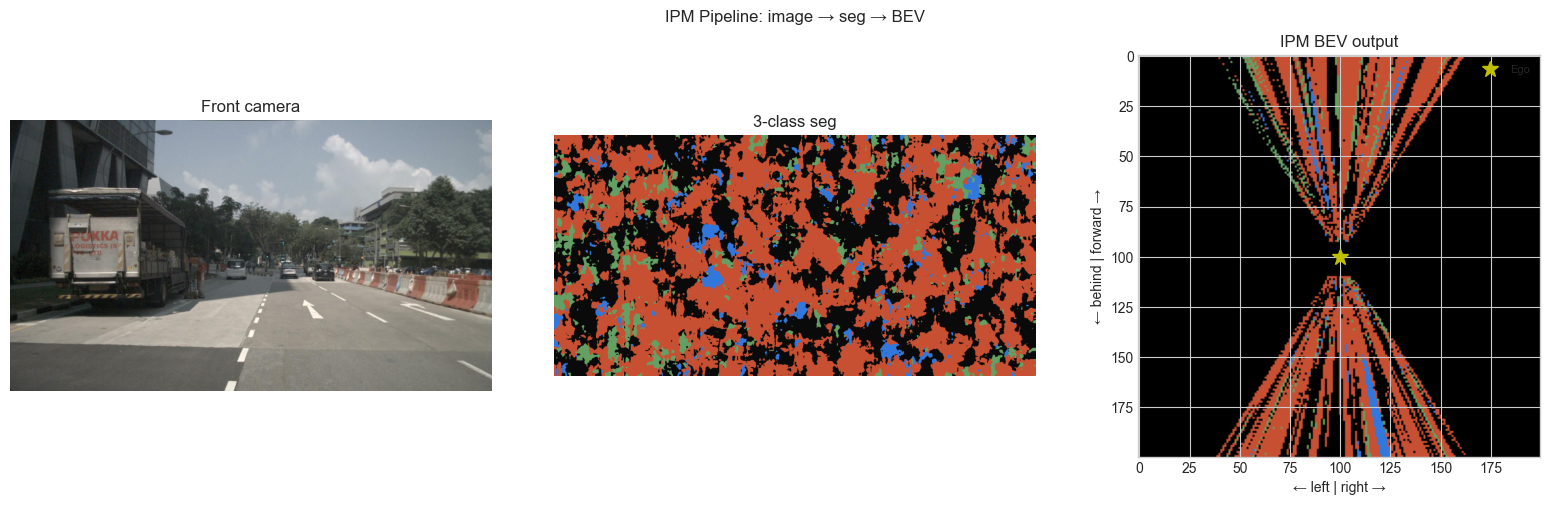

In [4]:
from ipm.warp import apply_ipm, bev_mask_to_channels
from viz.colorize import colorize_bev

bev_mask = apply_ipm(seg_3, H)
bev_ch   = bev_mask_to_channels(bev_mask)

print(f'BEV mask shape    : {bev_mask.shape}')
print(f'BEV mask unique   : {np.unique(bev_mask).tolist()}')
print(f'BEV channels shape: {bev_ch.shape}')
for i, name in enumerate(CLASSES["names"]):
    print(f'  {name}: {int(bev_ch[i].sum())} pixels')

bev_rgb = colorize_bev(bev_mask)   # single-channel label map

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(rgb);     axes[0].set_title('Front camera');   axes[0].axis('off')
axes[1].imshow(vis_3);   axes[1].set_title('3-class seg');    axes[1].axis('off')

axes[2].imshow(bev_rgb, origin='upper')
axes[2].set_title('IPM BEV output')
cx = BEV['size']//2
axes[2].plot(cx, cx, 'y*', markersize=12, label='Ego')
axes[2].set_xlabel('← left | right →')
axes[2].set_ylabel('← behind | forward →')
axes[2].legend(fontsize=8)

plt.suptitle('IPM Pipeline: image → seg → BEV')
plt.tight_layout(); plt.show()

## 4. Homography visualisation — source point mapping

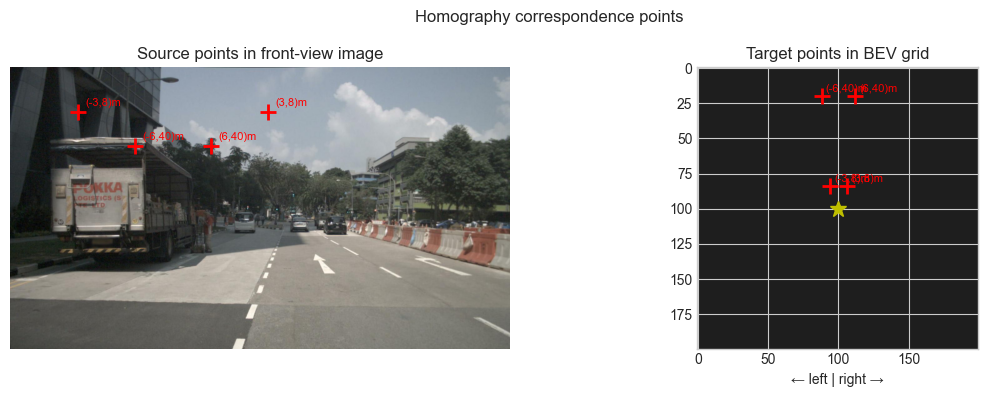

Red crosses show the 4 world points used to compute H.
These must lie on the ground plane (z=0) for IPM to be valid.


In [5]:
# show where the 4 world-point correspondences land in image vs BEV
h_cam = cam_h
fx, fy = K[0,0], K[1,1]
cx_k, cy_k = K[0,2], K[1,2]
sx = SEGFORMER['img_w'] / 1600.0
sy = SEGFORMER['img_h'] / 900.0

world_pts = [(-3,8),(3,8),(-6,40),(6,40)]
img_pts, bev_pts_vis = [], []
for x, y in world_pts:
    img_pts.append(((fx*(x/y)+cx_k)*sx, (fy*(-h_cam/y)+cy_k)*sy))
    bev_pts_vis.append((BEV['size']/2+x/BEV['resolution'],
                        BEV['size']/2-y/BEV['resolution']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(rgb)
for (u,v), (xw,yw) in zip(img_pts, world_pts):
    axes[0].plot(u, v, 'r+', markersize=12, markeredgewidth=2)
    axes[0].annotate(f'({xw},{yw})m', (u,v), textcoords='offset points',
                     xytext=(5,5), color='red', fontsize=8)
axes[0].set_title('Source points in front-view image')
axes[0].axis('off')

blank_bev = np.full((BEV['size'], BEV['size'], 3), 30, dtype=np.uint8)
axes[1].imshow(blank_bev, origin='upper')
for (bx,by), (xw,yw) in zip(bev_pts_vis, world_pts):
    axes[1].plot(bx, by, 'r+', markersize=12, markeredgewidth=2)
    axes[1].annotate(f'({xw},{yw})m', (bx,by), textcoords='offset points',
                     xytext=(3,3), color='red', fontsize=8)
axes[1].plot(BEV['size']//2, BEV['size']//2, 'y*', markersize=12)
axes[1].set_title('Target points in BEV grid')
axes[1].set_xlabel('← left | right →')

plt.suptitle('Homography correspondence points')
plt.tight_layout(); plt.show()
print('Red crosses show the 4 world points used to compute H.')
print('These must lie on the ground plane (z=0) for IPM to be valid.')

## 5. Boston vs Singapore — flat-ground assumption failure

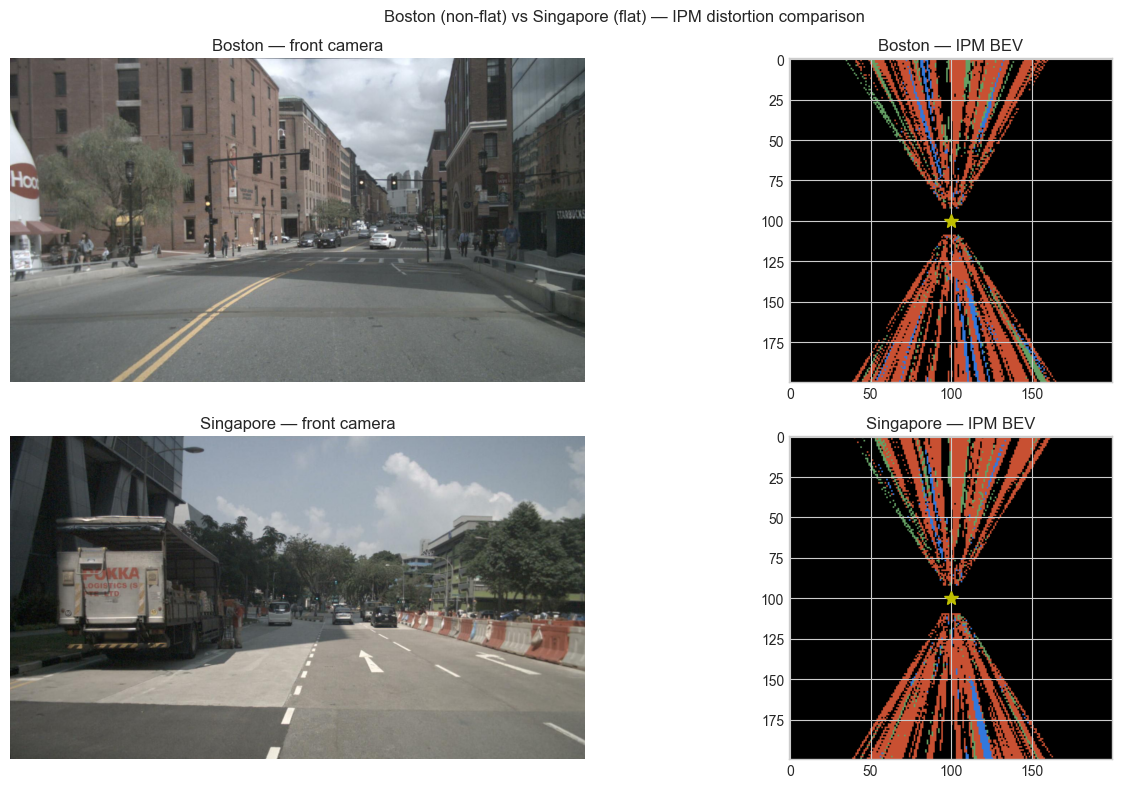

Boston has ramps + speed bumps → IPM flat-ground assumption breaks → distorted BEV.
Singapore is flatter → IPM more accurate.
This terrain difference is the key experiment in Phase 6 evaluation.


In [6]:
from data.nuscenes_loader import get_all_scene_tokens, iterate_scene_samples, get_scene_location
from ipm.pipeline import run_ipm_pipeline

boston_token = singapore_token = None
for sc in get_all_scene_tokens():
    loc = get_scene_location(sc)
    tok = next(iterate_scene_samples(sc))
    if 'boston' in loc and boston_token is None:
        boston_token = tok
    if 'singapore' in loc and singapore_token is None:
        singapore_token = tok
    if boston_token and singapore_token:
        break

def run_and_visualise(token, label):
    cam  = get_camera_data(token)
    bgr_ = cv2.imread(str(cam['image_path']))
    rgb_ = cv2.cvtColor(bgr_, cv2.COLOR_BGR2RGB)
    res  = run_ipm_pipeline(bgr_, cam['K'], sample_token=token,
                            model=model, device=device)
    bev_vis = colorize_bev(res['bev_mask'])
    return rgb_, bev_vis

b_rgb, b_bev = run_and_visualise(boston_token,    'Boston')
s_rgb, s_bev = run_and_visualise(singapore_token, 'Singapore')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].imshow(b_rgb);  axes[0,0].set_title('Boston — front camera');  axes[0,0].axis('off')
axes[0,1].imshow(b_bev, origin='upper');  axes[0,1].set_title('Boston — IPM BEV')
axes[0,1].plot(100,100,'y*',markersize=10)

axes[1,0].imshow(s_rgb);  axes[1,0].set_title('Singapore — front camera'); axes[1,0].axis('off')
axes[1,1].imshow(s_bev, origin='upper');  axes[1,1].set_title('Singapore — IPM BEV')
axes[1,1].plot(100,100,'y*',markersize=10)

plt.suptitle('Boston (non-flat) vs Singapore (flat) — IPM distortion comparison')
plt.tight_layout(); plt.show()

print('Boston has ramps + speed bumps → IPM flat-ground assumption breaks → distorted BEV.')
print('Singapore is flatter → IPM more accurate.')
print('This terrain difference is the key experiment in Phase 6 evaluation.')

## 6. Multi-frame IPM strip — temporal consistency

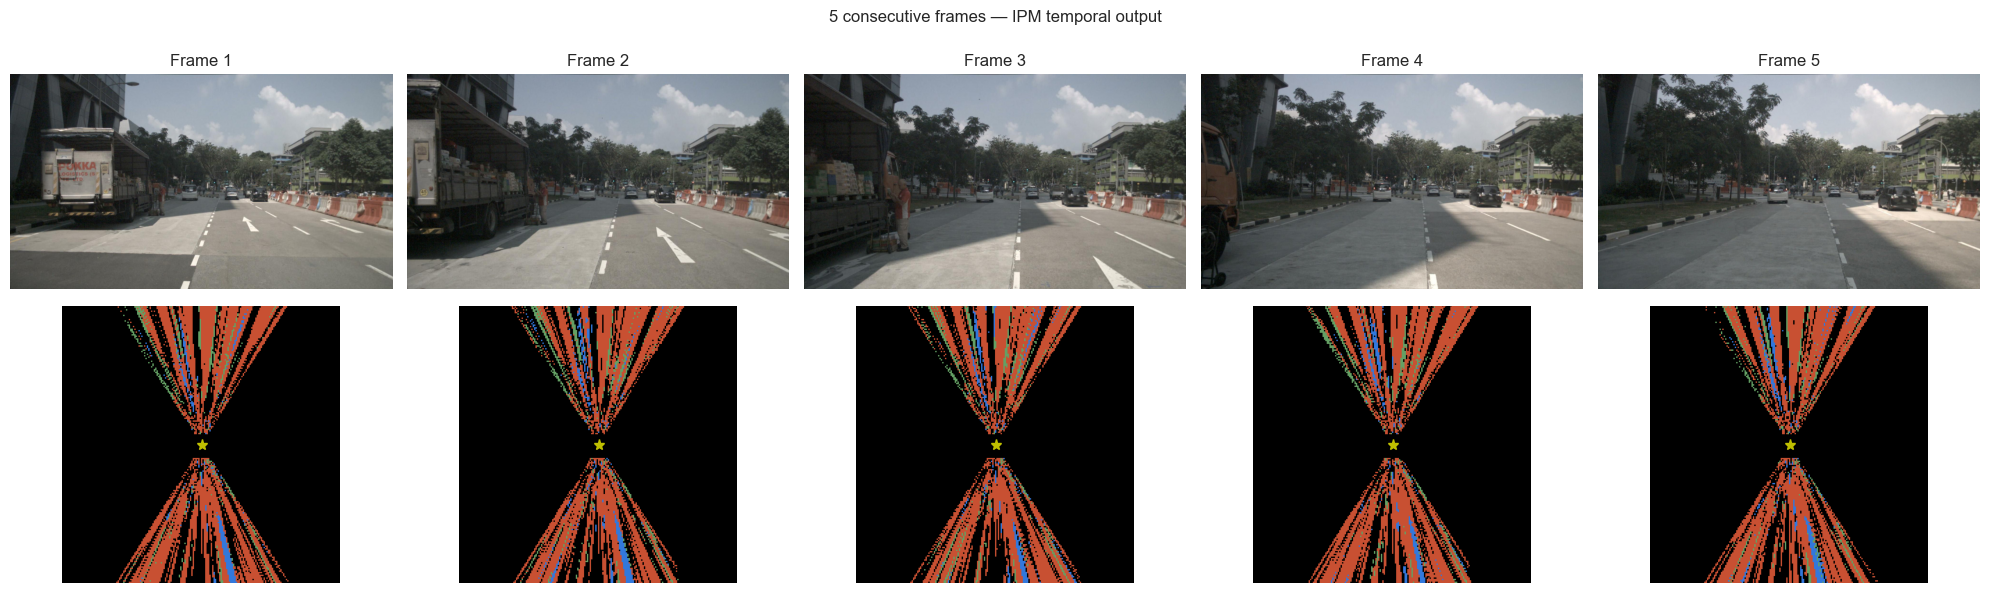

Note: each frame is processed independently — no temporal smoothing.
Flickering between frames is expected and is a known limitation of frame-by-frame IPM.


In [7]:
from data.nuscenes_loader import get_all_scene_tokens, iterate_scene_samples
from ipm.pipeline import run_ipm_pipeline
import itertools

scene_token = get_all_scene_tokens()[0]
tokens_5    = list(itertools.islice(iterate_scene_samples(scene_token), 5))

fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, tok in enumerate(tokens_5):
    cam  = get_camera_data(tok)
    bgr_ = cv2.imread(str(cam['image_path']))
    rgb_ = cv2.cvtColor(bgr_, cv2.COLOR_BGR2RGB)
    res  = run_ipm_pipeline(bgr_, cam['K'], sample_token=tok,
                            model=model, device=device)
    bev_vis = colorize_bev(res['bev_mask'])

    axes[0,i].imshow(rgb_)
    axes[0,i].set_title(f'Frame {i+1}')
    axes[0,i].axis('off')

    axes[1,i].imshow(bev_vis, origin='upper')
    axes[1,i].plot(100, 100, 'y*', markersize=8)
    axes[1,i].axis('off')

axes[1,0].set_ylabel('IPM BEV')
plt.suptitle('5 consecutive frames — IPM temporal output')
plt.tight_layout(); plt.show()

print('Note: each frame is processed independently — no temporal smoothing.')
print('Flickering between frames is expected and is a known limitation of frame-by-frame IPM.')

## Summary

If all cells ran:
- IPM homography computed from calibration ✓
- BEV mask shape (200,200) with {0,1,2,255} values ✓
- Boston vs Singapore comparison visible ✓

Run verification then proceed:
```bash
python scripts/verify_phase3.py
```